In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools 

datafolder='/space/gzanardini/tuh/tuh_ensemble_bucket/'

files=[file for file in os.listdir(datafolder) if file.endswith('.csv')]
print(files)

plt.style.use('ggplot')

['cc+dwt+plv+sst+utm+gcc+gplv_run_0_run_0_results_seed_1954.csv', 'cc+cwt+dwt+gcc+gplv_run_1_run_1_results_seed_3105.csv', 'cc+cwt+plv+mst+gcc+gplv_run_4_run_4_predictions_seed_4552.csv', 'cc+plv+mst+gcc+gplv_run_4_run_4_results_seed_2446.csv', 'cwt+dwt+plv+mst+gplv_run_4_run_4_predictions_seed_56.csv', 'cc+cwt+dwt+sst+spectral+gcc+gplv_run_3_run_3_predictions_seed_4013.csv', 'dwt+plv+mst+sst+spectral+gcc+gplv_run_4_run_4_predictions_seed_4714.csv', 'cc+dwt+sst+spectral+utm_run_2_run_2_predictions_seed_3648.csv', 'dwt+plv+mst+gcc_run_1_run_1_predictions_seed_2902.csv', 'cwt+plv+gcc_run_4_run_4_results_seed_1219.csv', 'cc+cwt+dwt+mst+spectral+utm_run_3_run_3_predictions_seed_3501.csv', 'cwt+mst+gplv_run_4_run_4_results_seed_4067.csv', 'cwt+dwt+plv+mst+sst+spectral+gcc+gplv_run_4_run_4_results_seed_4410.csv', 'cc+cwt+plv+sst+gcc_run_2_run_2_predictions_seed_3344.csv', 'cwt+plv+spectral+utm_run_1_run_1_predictions_seed_1072.csv', 'cc+cwt+dwt+plv+sst+spectral+utm+gcc+gplv_run_4_run_4_resul

In [8]:
def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """
    Linear interpolation of TPR at FPR = x between points (p1_fpr, p1_tpr) and (p2_fpr, p2_tpr).
    """
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)


def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """
    Implements Algorithm 3's helper that finds / interpolates TPR at a specific FPR.
    Assumes fpr_arr is sorted ascending and has the same length as tpr_arr.
    """
    # Locate the rightmost point whose FPR ≤ fprsample
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    # Edge cases: before first point or exactly at end
    if i < 0:                     # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    # Otherwise interpolate between point i and i+1
    return interpolate(fpr_arr[i], tpr_arr[i],
                       fpr_arr[i + 1], tpr_arr[i + 1],
                       fprsample)

def vertical_avg_roc(roc_data):
    '''
    ROC curve averaging function.
    Takes a list of ROC data (each element is a tuple of fpr, tpr, thresholds)
    all the fpr values are concatenated and sorted, then the fpr of each curve is sampled
    at these points, and then averaged
    :param roc_data: list of tuples (fpr, tpr, thresholds)
    :return: tuple (fpr, tpr) of the averaged ROC curve 
    '''
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)
    
    fprs = np.sort(np.unique(fprs))
    tprs=np.zeros(shape=(len(roc_data),len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx,(fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr



In [9]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,  roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix, balanced_accuracy_score
from sklearn.metrics import auc as sk_auc
def calculate_bac(labels, scores, sens_thresh):
    """Calculate balanced accuracy with sensitivity threshold."""
    fpr, tpr, thresholds = roc_curve(labels, scores)
    threshold_sensitivity = thresholds[np.where(tpr >= sens_thresh)[0][0]]
    adjusted_predictions = (scores >= threshold_sensitivity).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, adjusted_predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    bac = ((sensitivity + specificity) / 2)
    return bac, fpr, tpr, thresholds

In [10]:
feature_names = ['cc', 'cwt', 'dwt', 'plv', 'mst', 'sst', 'spectral', 'utm', 'gcc', 'gplv']

combinations =[] # Generate all combinations of 2 to len(feature_names) features
comb_names=[]
for i in range(2, len(feature_names) + 1):
    combs = list(itertools.combinations(feature_names, i))
    for comb in combs:
        combinations.append(list(comb))
        comb_names.append( '+'.join(list(comb)))

com_w_names = zip(combinations, comb_names)

df_summary= pd.DataFrame(columns=['combination', 'length', 'accuracy','bac','bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc']) 

for comb, name in com_w_names:
    #print(len(comb), len(name))
    comb_files = [file for file in files if (file.startswith(name+'_') and 'predictions' in file)]

    for file in comb_files:

        df_file = pd.read_csv(datafolder + file)
        accuracy = accuracy_score(df_file['y_true'], df_file['y_pred'])
        f1 = f1_score(df_file['y_true'], df_file['y_pred'])
        precision = precision_score(df_file['y_true'], df_file['y_pred'])
        recall= recall_score(df_file['y_true'], df_file['y_pred'])
        auc = roc_auc_score(df_file['y_true'], df_file['y_prob'])
        bac = balanced_accuracy_score(df_file['y_true'], df_file['y_pred'])
        bac80, fpr, tpr, thresholds = calculate_bac(df_file['y_true'], df_file['y_prob'], 0.80)
        p,r, t = precision_recall_curve(df_file['y_true'], df_file['y_prob'])
        auprc= sk_auc(r, p)

        df_summary = pd.concat([df_summary, pd.DataFrame([[name, len(comb), accuracy, bac, bac80, f1, precision, recall, auc, auprc]], 
                                        columns=['combination', 'length', 'accuracy','bac','bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc'])], ignore_index=True) 

#y_true  y_pred    y_prob

In [11]:
avg_df= df_summary.groupby('combination').mean().reset_index()

# insert a column with the length of the combination name
avg_df['length'] = avg_df['combination'].apply(lambda x: len(x.split('+')))

# for each of length [2,3,4,5,6,7,8,9,10], find the best combination based on auc
df_best= pd.DataFrame(columns=['length', 'combination', 'accuracy','bac','bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc'])
for length in range(2, 11):
    df_length = avg_df[avg_df['length'] == length]
    if df_length.empty:
        continue
    # create a column with auc+auprc
    df_length['metric'] = df_length['auc'] + df_length['auprc']+ df_length['bac80']
    # find the best combination based on auc+auprc
    best_combination = df_length.loc[df_length['metric'].idxmax()]
    df_best = pd.concat([df_best, pd.DataFrame([best_combination], columns=df_best.columns)], ignore_index=True)

print(df_best)

  length                                   combination  accuracy       bac  \
0      2                                        cc+utm     0.680  0.651282   
1      3                                   cc+dwt+gplv     0.735  0.719943   
2      4                           cc+mst+spectral+utm     0.710  0.717379   
3      5                       cc+cwt+dwt+sst+spectral     0.750  0.754986   
4      6                   cc+cwt+dwt+mst+sst+spectral     0.735  0.731909   
5      7                    cc+cwt+dwt+mst+sst+utm+gcc     0.730  0.692308   
6      8               cc+cwt+dwt+plv+mst+sst+gcc+gplv     0.710  0.685470   
7      9      cc+cwt+plv+mst+sst+spectral+utm+gcc+gplv     0.645  0.617379   
8     10  cc+cwt+dwt+plv+mst+sst+spectral+utm+gcc+gplv     0.665  0.640171   

      bac80  f1_score  precision    recall       auc     auprc  
0  0.764387  0.531373   0.506886  0.569231  0.778348  0.548218  
1  0.738462  0.614524   0.575518  0.676923  0.754416  0.609843  
2  0.753276  0.624712   

/tmp/ipykernel_3072098/666036091.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  avg_df= df_summary.groupby('combination').mean().reset_index()
/tmp/ipykernel_3072098/666036091.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_length['metric'] = df_length['auc'] + df_length['auprc']+ df_length['bac80']
/tmp/ipykernel_3072098/666036091.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [12]:
std_df = df_summary.groupby('combination').std().reset_index()
std_df['length'] = std_df['combination'].apply(lambda x: len(x.split('+')))

combinations = df_best['combination'].tolist()

# in the std_df only keep the combinations that are in df_best
std_df = std_df[std_df['combination'].isin(combinations)]
#sort by length and reset index
std_df = std_df.sort_values(by='length').reset_index(drop=True)

print(std_df)


                                    combination  accuracy       bac     bac80  \
0                                        cc+utm  0.075829  0.095220  0.083303   
1                                   cc+dwt+gplv  0.065192  0.095641  0.143446   
2                           cc+mst+spectral+utm  0.084039  0.089871  0.068874   
3                       cc+cwt+dwt+sst+spectral  0.075000  0.075780  0.039789   
4                   cc+cwt+dwt+mst+sst+spectral  0.114018  0.101352  0.067949   
5                    cc+cwt+dwt+mst+sst+utm+gcc  0.121707  0.130872  0.124016   
6               cc+cwt+dwt+plv+mst+sst+gcc+gplv  0.033541  0.044187  0.123855   
7      cc+cwt+plv+mst+sst+spectral+utm+gcc+gplv  0.059687  0.058825  0.081355   
8  cc+cwt+dwt+plv+mst+sst+spectral+utm+gcc+gplv  0.084039  0.106508  0.093530   

   f1_score  precision    recall       auc     auprc  length  
0  0.122127   0.109580  0.177090  0.065011  0.046519       2  
1  0.129997   0.096524  0.206406  0.127099  0.198133       3  


/tmp/ipykernel_3072098/3063693853.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  std_df = df_summary.groupby('combination').std().reset_index()


Processing combination: cc+utm with files: ['cc+utm_run_4_run_4_predictions_seed_2707.csv', 'cc+utm_run_2_run_2_predictions_seed_966.csv', 'cc+utm_run_3_run_3_predictions_seed_830.csv', 'cc+utm_run_1_run_1_predictions_seed_2529.csv', 'cc+utm_run_0_run_0_predictions_seed_531.csv']
Processing combination: cc+dwt+gplv with files: ['cc+dwt+gplv_run_4_run_4_predictions_seed_3894.csv', 'cc+dwt+gplv_run_2_run_2_predictions_seed_2521.csv', 'cc+dwt+gplv_run_0_run_0_predictions_seed_2931.csv', 'cc+dwt+gplv_run_1_run_1_predictions_seed_99.csv', 'cc+dwt+gplv_run_3_run_3_predictions_seed_3372.csv']
Processing combination: cc+mst+spectral+utm with files: ['cc+mst+spectral+utm_run_4_run_4_predictions_seed_949.csv', 'cc+mst+spectral+utm_run_1_run_1_predictions_seed_2093.csv', 'cc+mst+spectral+utm_run_3_run_3_predictions_seed_1632.csv', 'cc+mst+spectral+utm_run_0_run_0_predictions_seed_2015.csv', 'cc+mst+spectral+utm_run_2_run_2_predictions_seed_1815.csv']
Processing combination: cc+cwt+dwt+sst+spectra

<Figure size 3000x800 with 0 Axes>

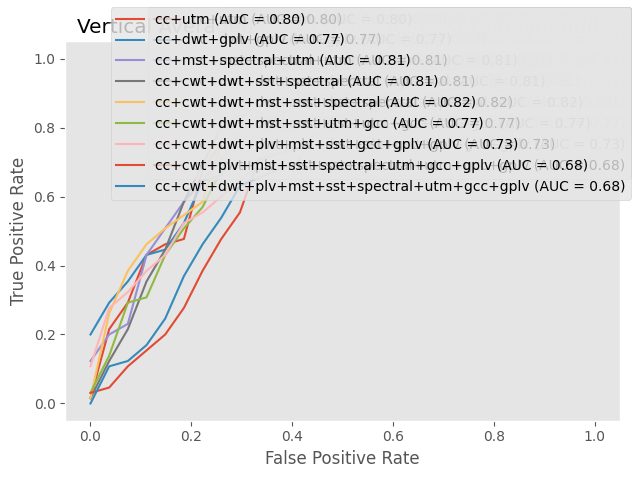

In [13]:
# for each of the best combinations, retrieve the corresponding files and plot the vertical averaged ROC for that combination

plt.figure(figsize=(30, 8))
fig, ax = plt.subplots(1,1)

for index, row in df_best.iterrows():
    comb = row['combination']
    comb_files = [file for file in os.listdir(datafolder) if file.startswith(comb + '_') and 'predictions' in file]
    print(f"Processing combination: {comb} with files: {comb_files}")
    
    roc_data = []
    for file in comb_files:
        df_file = pd.read_csv(datafolder + file)
        fpr,tpr, thresholds = roc_curve(df_file['y_true'], df_file['y_prob'])
        roc_data.append((fpr, tpr, thresholds))
    
    fpr_avg, tpr_avg = vertical_avg_roc(roc_data)
    auc_avg = sk_auc(fpr_avg, tpr_avg)
    ax.plot(fpr_avg, tpr_avg, label=f"{comb} (AUC = {auc_avg:.2f})")
    fig.legend(loc='outside upper right')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Vertical Averaged ROC Curves for Best Combinations')
plt.grid()
plt.tight_layout()
plt.show()